# Student Performance Analysis

This notebook explores the Student Performance dataset with a simple data science workflow: load, clean, analyze, visualize, and conclude.

## 1. Load the Dataset

We use pandas to read the `student-mat.csv` file. The dataset uses semicolons as separators, so we pass `sep=';'`.

In [ ]:
%pip install pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('student-mat.csv', sep=';')

for column in ['G1', 'G2', 'G3']:
    df[column] = pd.to_numeric(df[column])

df.head()


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 2. Explore and Clean the Data

First, we check the shape, data types, missing values, and duplicates. Then we create a cleaned copy of the dataset by removing duplicate rows.

In [ ]:
print('Shape:', df.shape)
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Data types:')
print(df.dtypes)

df_clean = df.drop_duplicates().copy()
print()
print('Original rows:', len(df))
print('Cleaned rows:', len(df_clean))
print('Removed duplicates:', len(df) - len(df_clean))

Shape: (395, 33)
Missing values per column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Data types:
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
hi

## 3. Analysis Questions

We answer four questions about the final grade `G3`, study time, and gender performance.

In [ ]:
average_g3 = df_clean['G3'].mean()
above_15 = (df_clean['G3'] > 15).sum()
studytime_corr = df_clean['studytime'].corr(df_clean['G3'])
gender_scores = df_clean.groupby('sex')['G3'].mean().sort_index()

print(f'Average final grade (G3): {average_g3:.2f}')
print(f'Students scoring above 15: {above_15}')
print(f'Correlation between study time and final grade: {studytime_corr:.3f}')
print()
print('Average final grade by gender:')
print(gender_scores.round(2))

Average final grade (G3): 10.42
Students scoring above 15: 40
Correlation between study time and final grade: 0.098

Average final grade by gender:
sex
F     9.97
M    10.91
Name: G3, dtype: float64


### Quick Answers

- Average final grade (`G3`): **10.42**
- Students scoring above 15: **40**
- Study time vs. final grade correlation: **0.098**
- Average final grade by gender: **F = 9.97**, **M = 10.91**

The study time correlation is weak and positive, which suggests study time has a small relationship with final performance in this dataset. Males have a slightly higher average final grade.

## 4. Visualizations

We use three plots: a histogram of final grades, a scatterplot of study time versus grades, and a bar chart comparing average scores by gender.

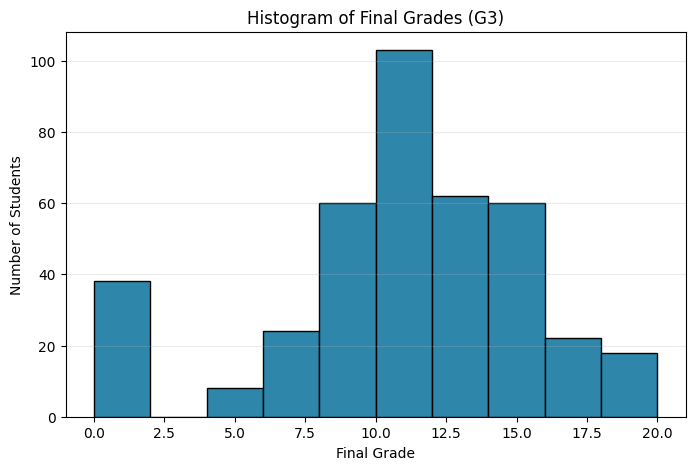

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean['G3'], bins=10, color='#2E86AB', edgecolor='black')
plt.title('Histogram of Final Grades (G3)')
plt.xlabel('Final Grade')
plt.ylabel('Number of Students')
plt.grid(axis='y', alpha=0.25)
plt.show()

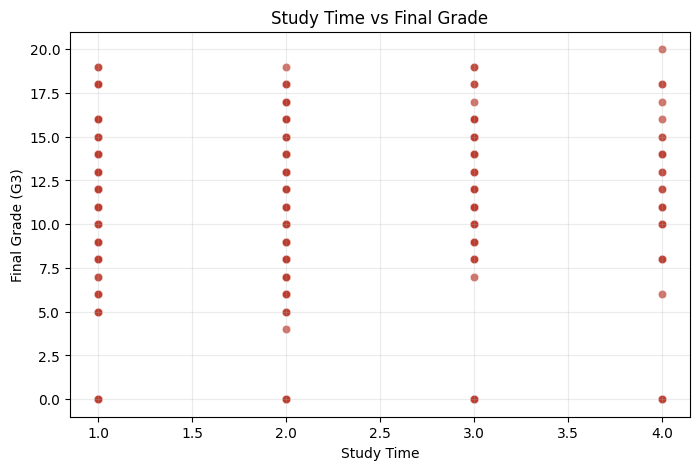

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df_clean['studytime'], df_clean['G3'], alpha=0.7, color='#C0392B', edgecolors='white', linewidths=0.4)
plt.title('Study Time vs Final Grade')
plt.xlabel('Study Time')
plt.ylabel('Final Grade (G3)')
plt.grid(alpha=0.25)
plt.show()

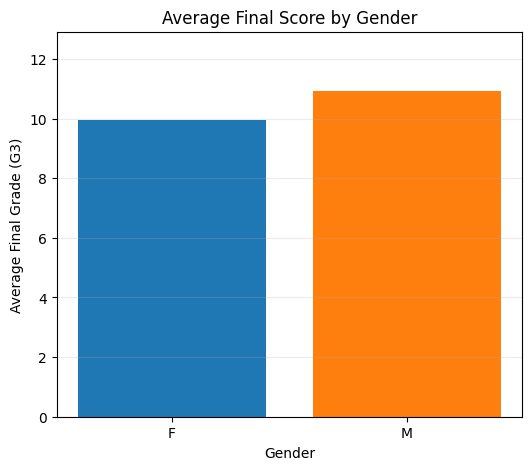

In [ ]:
gender_scores = df_clean.groupby('sex')['G3'].mean()

plt.figure(figsize=(6, 5))
plt.bar(gender_scores.index, gender_scores.values, color=['#1F77B4', '#FF7F0E'])
plt.title('Average Final Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Final Grade (G3)')
plt.ylim(0, max(gender_scores.values) + 2)
plt.grid(axis='y', alpha=0.25)
plt.show()

## 5. Conclusion

The dataset has no missing values or duplicates in the current file. The average final grade is 10.42, and 40 students scored above 15. Study time shows only a weak positive relationship with final grade, so it is not a strong predictor by itself. On average, male students scored slightly higher than female students in this dataset.